# **Deep Reinforcement Learning Class Spring 2026 Assignment 1**

In this assignment, we will learn about gym interface, gridworld, q-learning, and etc. You will need to answer the bolded questions and fill in the missing code snippets (marked by TODO).

Make a copy of this notebook using File > Save a copy in Drive and edit it with your answers.

# **Question 1:** Implement and Familiarize Yourself with a Grid World Environment
We will first become familiar with the grid world environment.

In this question, you need to implement a simple 5×5 grid world from scratch. Specifically, you should define functions such as reset(), step(), and render().

Additionally, you should explore and gain familiarity with MiniGrid in OpenAI Gym.

To define our GridWorldEnv.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

class GridWorldEnv:
    def __init__(self, size=5):
        self.size = size
        self.agent_pos = [0, 0]  # Start position
        self.goal_pos = [size - 1, size - 1]  # Goal position
        self.done = False

    def reset(self):
        # TODO: Reset the agent's position to (0,0)
        self.agent_pos = [0, 0]

        # TODO: Set `done` to False
        self.done = False

        # TODO: Return the initial state as a NumPy array
        return np.array(self.agent_pos)


    def step(self, action):
        # TODO: Implement movement logic based on the given action
        if action == 0:  # Up (↑)
            self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
        elif action == 1:  # Right (→)
            self.agent_pos[1] = min(self.size - 1, self.agent_pos[1] + 1)
        elif action == 2:  # Down (↓)
            self.agent_pos[0] = min(self.size - 1, self.agent_pos[0] + 1)
        elif action == 3:  # Left (←)
            self.agent_pos[1] = max(0, self.agent_pos[1] - 1)

        # TODO: Implement reward logic
        # After moving, calculate the reward (+5 for goal, -0.2 per step) and set `done=True`
        if self.agent_pos == self.goal_pos:
            reward = 5  # Goal reached
            self.done = True
        else:
            reward = -0.2  # Step penalty

        # TODO: Return the new state (NumPy array), reward, and `done` status
        return np.array(self.agent_pos), reward, self.done

    def render(self):

        '''
        Render the environment
        Draw the grid, marking the agent and the goal
        '''

        # TODO: Create a grid of zeros with shape (size, size)
        grid = np.zeros((self.size, self.size))

        # TODO: Mark the goal position with 2
        grid[self.goal_pos[0], self.goal_pos[1]] = 2

        # TODO: Mark the agent position with 1
        grid[self.agent_pos[0], self.agent_pos[1]] = 1

        # TODO: Display the grid using matplotlib
        plt.imshow(grid, cmap='viridis', vmin=0, vmax=2)
        plt.xticks([])
        plt.yticks([])
        plt.title('Grid World Environment')
        plt.show()

This cell of code is designed to verify whether your implementation of the MiniGrid environment is correct.

⚠️ **Do not modify this cell**—any changes will result in a score of **0** for your own GridWorldEnv code above.

🎯 How to Get 7 Points?  
 1️⃣ Run the code below successfully.  
 2️⃣ Observe the agent randomly moving in the 3x3 GridWorld.(2 pts for reset/ 2 pts for render)  
 3️⃣ The agent should reach the goal (🏆) eventually and stop.(3pts for step)  
 4️⃣ If everything works, congratulations! You earned 7 points! 🎉  

🚀 Random Action Agent Starts!


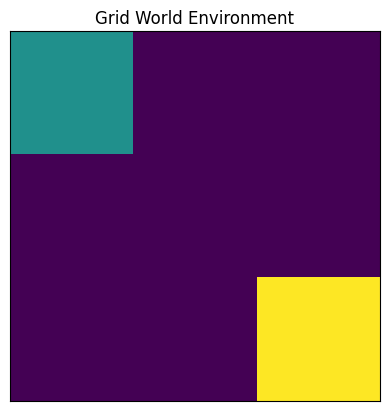

Action: 3, Reward: -0.2, Done: False


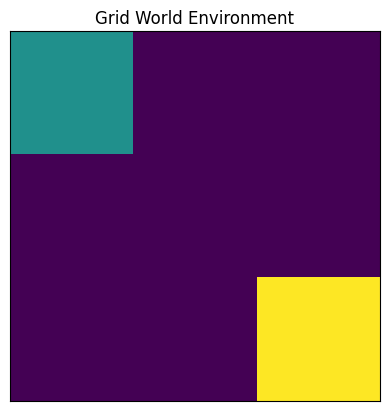

Action: 3, Reward: -0.2, Done: False


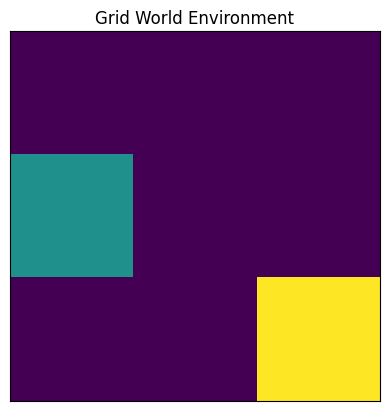

Action: 2, Reward: -0.2, Done: False


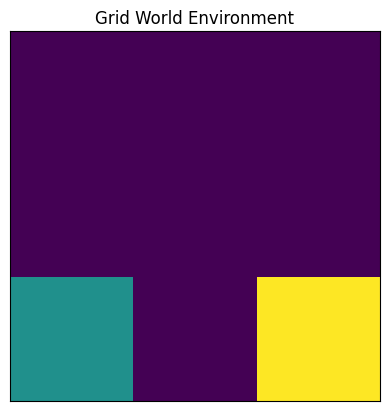

Action: 2, Reward: -0.2, Done: False


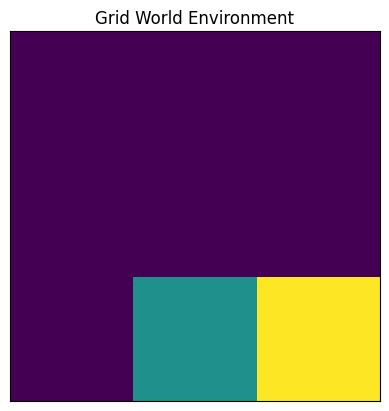

Action: 1, Reward: -0.2, Done: False


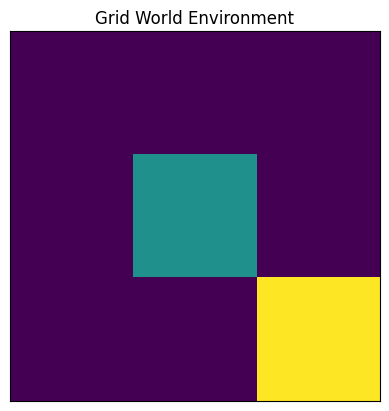

Action: 0, Reward: -0.2, Done: False


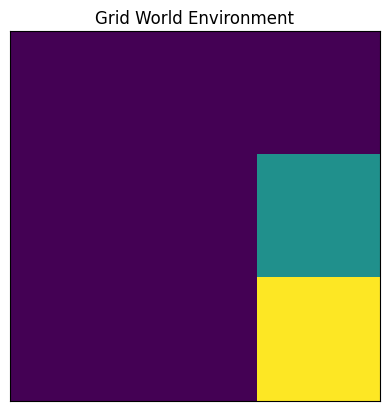

Action: 1, Reward: -0.2, Done: False


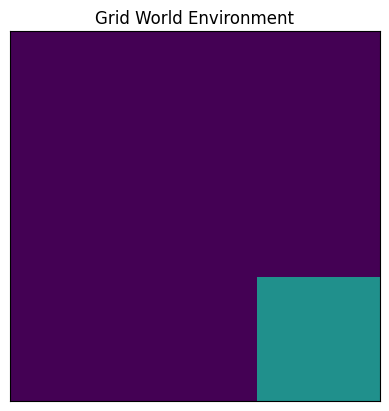

Action: 2, Reward: 5, Done: True


In [2]:
import random

env = GridWorldEnv(size=3)
obs = env.reset()
done = False

print("🚀 Random Action Agent Starts!")
while not done:
    action = random.choice([0, 1, 2, 3])
    obs, reward, done = env.step(action)
    env.render()
    print(f"Action: {action}, Reward: {reward}, Done: {done}")
    time.sleep(0.5)


## **Setup**
Run the following skeleton code to set up the necessary imports and plotting functions.

In [3]:
!pip -q install -U gymnasium minigrid matplotlib imageio
import gymnasium as gym
import minigrid
import imageio
from IPython.display import Image, display
import math

## **Understanding the Gym MiniGrid Environment**
In this section, we will initialize a MiniGrid environment and explore its key properties.

***What is MiniGrid?***

MiniGrid is a lightweight grid world environment designed for reinforcement learning. The agent interacts with the environment by taking actions, receiving observations, and collecting rewards. It serves as an ideal testing ground for developing and evaluating reinforcement learning algorithms.

Simply execute this cell to retrieve key information about the environment.

In [4]:
# setup Environment
env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")

obs, info = env.reset()

# environment information
print("Action Space:", env.action_space)
print("Observation Keys:", obs.keys())
print("Observation Shape:", obs['image'].shape)

Action Space: Discrete(7)
Observation Keys: dict_keys(['image', 'direction', 'mission'])
Observation Shape: (7, 7, 3)


## **Implementing a Random Agent in MiniGrid**
In this section, you will implement a random agent in the MiniGrid environment. This exercise will help you understand how the agent interacts with the environment by taking actions, receiving rewards, and updating the environment state.

🎯 How to Get 3 Points?  
 1️⃣ Successfully execute the following code.  
 2️⃣ The random agent should move freely in the environment.  
 3️⃣ The animation of the agent’s movement should be generated.  
 4️⃣ The total accumulated reward should be displayed.  
 5️⃣ If everything works correctly, congratulations! You earned 3 points! 🎉  


Total Reward: 0.314453125


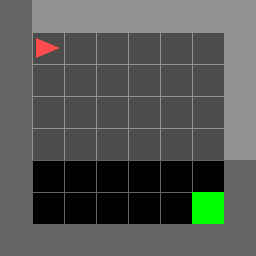

In [5]:
# Setup environment (render_mode is required to get RGB frames via env.render()).
env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")
obs, info = env.reset()

frames = []          # Stores rendered frames for GIF export
total_reward = 0.0   # Accumulates episode reward
max_steps = 200      # Safety cap to avoid infinite loops

for t in range(max_steps):
    # TODO: Select an action randomly
    action = env.action_space.sample()
    # TODO: Take a step in the environment
    obs, reward, terminated, truncated, info = env.step(action)
    # TODO: Update the total reward
    total_reward += reward

    # Render current frame as an RGB array.
    frame = env.render()

    frames.append(frame.copy())

    if terminated or truncated:
        break

print("Total Reward:", total_reward)

# gif_path = "/content/minigrid.gif"
gif_path = "minigrid.gif"
imageio.mimsave(gif_path, frames, fps=5)
Image(filename=gif_path)

Simply execute this cell to explore the available actions that an agent can take in the MiniGrid environment. Understanding these actions will help you better navigate and interact with the environment.

In [6]:
actions_enum = env.unwrapped.actions  # Actions Enum class (MiniGrid)
actions = {i: actions_enum(i).name for i in range(env.action_space.n)}
print("Available Actions:", actions)

Available Actions: {0: 'left', 1: 'right', 2: 'forward', 3: 'pickup', 4: 'drop', 5: 'toggle', 6: 'done'}


## **Implementing a Rule-Based Agent in MiniGrid**
In this section, you will implement a **simple rule-based agent** to navigate the **MiniGrid environment**. This will help you gain a deeper understanding of **observations**, **actions**, and **rewards** before progressing to **reinforcement learning**.

🎯 How to Get 5 Points?  
 1️⃣ Successfully execute the following code.  
 2️⃣ The rule-based agent should move based on rule in the environment.  
 3️⃣ The animation of the agent’s movement should be generated.  
 4️⃣ The total accumulated reward should be displayed.  
 5️⃣ If everything works correctly, congratulations! You earned 5 points! 🎉  

Total Reward: 0.961328125


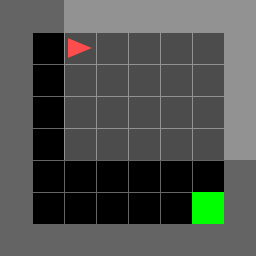

In [7]:
def rule_based_agent(obs):
    '''
      Simple Rule-Based Agent:
        Turns if a wall is ahead
        Otherwise, Moves forward
    '''
    goal_id, wall_id, agent_id = 8, 2, 10  # TODO: Define the object IDs for the goal, walls, and agent
    direction = obs['direction']  # TODO: Retrieve the agent's current facing direction

    # TODO: Find the agent's position within the observation grid (obs['image'])
    agent_pos = np.argwhere(obs['image'][:, :, 0] == agent_id)

    # TODO: Extract the agent's coordinates
    if len(agent_pos) > 0:
        agent_x, agent_y = agent_pos[0]
    else:
        agent_x, agent_y = 3, 6
    
    # TODO: Calculate the coordinates of the cell directly in front of the agent based on its direction
    front_x, front_y = agent_x, agent_y - 1

    # TODO: Ensure `front_x, front_y` remains within valid grid boundaries
    front_x = max(0, min(front_x, obs['image'].shape[0] - 1))
    front_y = max(0, min(front_y, obs['image'].shape[1] - 1))

    # TODO: Implement decision-making logic (Turns if a wall is ahead && Otherwise, Moves forward)
    if obs['image'][front_x, front_y, 0] == wall_id:
        return 1  # Turn Right (→)
    else:
        return 2  # Move Forward (↑)

done = False
total_reward = 0
frames = []

obs, info = env.reset()

while not done:
    action = rule_based_agent(obs)  # Execute the rule-based policy

    obs, reward, terminated, truncated, info = env.step(action)
    # TODO: Update termination condition using terminated/truncated
    done = terminated or truncated
    total_reward += float(reward)

    frame = env.render()
    frames.append(frame.copy())

# Do not modify the follwing code—any changes will result in a score of **0** for this cell.
print("Total Reward:", total_reward)

# gif_path = "/content/minigrid.gif"
gif_path = "minigrid.gif"
imageio.mimsave(gif_path, frames, fps=5)

Image(filename=gif_path)

# **Question 2: Reinforcement Learning with Tabular Methods**

In this section, we will explore **reinforcement learning (RL)** by implementing tabular-based **value learning** and **policy learning** in MiniGrid environments.

You will investigate two fundamental approaches in reinforcement learning:

## **📌 Value-Based Learning (Q-Learning)**
- Uses a **Q-table** to store action-value estimates for each state.
- The agent **updates Q-values** based on rewards received from the environment.
- Helps the agent **learn an optimal policy** by maximizing future rewards.

## **📌 Policy-Based Learning**
- Instead of learning a Q-table, it **learns a direct policy** (i.e., a mapping from states to actions).
- Can be implemented using **tabular-based policy iteration**.
- Helps understand how an agent can **directly optimize its behavior** without relying on Q-values.


## **Value-Based Learning (Q-Learning)**  

- Uses **Q-tables** to store action values for each state.  
- Applies the **Bellman equation** to update Q-values.  
- Implements **ε-greedy exploration** to balance exploration and exploitation.  


🎯 **How to Get 10 Points?**  
1️⃣ Correctly implement the **Q-learning training procedure**.  
2️⃣ The agent must be trained using **Q-tables** and the training loop should update Q-values properly.  

3️⃣ After training, successfully **demonstrate the learned policy** in the environment.  
4️⃣ Generate an **animation (GIF/video)** showing the trained agent running in the environment.  

5️⃣ You get **10 points only if both** the training process is correctly implemented **and** the animation is successfully displayed/generated. 🎉  


In [8]:
def tabular_q_learning(env_name="MiniGrid-Empty-8x8-v0", episodes=5000, alpha=0.1, gamma=0.99,
                       epsilon_start=1.0, epsilon_end=0.1, decay_rate=0.999):
    '''
      Implementing Tabular Q-Learning with Epsilon Decay
      - Uses a **Q-table** to store action values for each state.
      - Updates Q-values using the **Bellman equation**.
      - Implements **ε-greedy exploration** for action selection.
    '''


    env = gym.make(env_name)
    q_table = {}  # Initialize an empty Q-table to store state-action values.

    rewards_per_episode = []
    epsilon = epsilon_start  # Initialize epsilon for the exploration-exploitation tradeoff.

    def get_state(env):
        # TODO: Represent the state using the agent's position and direction.
        pos = env.unwrapped.agent_pos  # Get the agent's position (x, y)
        dir = env.unwrapped.agent_dir  # Get the agent's direction (0-3)
        return (pos[0], pos[1], dir)  # Return a tuple representing the state (x, y, direction)

    for episode in range(episodes):
        # TODO: Reset the environment at the beginning of each episode.
        obs, info = env.reset()
        state = get_state(env)

        done = False
        total_reward = 0.0
        while not done:
            # TODO: Initialize the state in the Q-table if it is not already present.
            if state not in q_table:
                q_table[state] = np.zeros(env.action_space.n)

            # TODO: Implement an ε-greedy policy for action selection.
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()  # Explore: select a random action
            else:
                action = np.argmax(q_table[state])  # Exploit: select the action with max Q-value
            
            # TODO: Execute the action and observe the next state and reward.
            obs, reward, terminated, truncated, info = env.step(action)

            # TODO: Update termination condition using terminated/truncated.
            done = terminated or truncated

            next_state = get_state(env)
            total_reward += float(reward)

            # TODO: Initialize next_state in the Q-table if it is not already present.
            if next_state not in q_table:
                q_table[next_state] = np.zeros(env.action_space.n)

            # TODO: Apply the Q-learning update rule (Bellman equation).
            if terminated:
                best_next_q = 0  # If terminated, there are no future rewards
            else:
                best_next_q = np.max(q_table[next_state])  # Max Q-value for the next state

            td_target = reward + gamma * best_next_q
            q_table[state][action] += alpha * (td_target - q_table[state][action])  # Update Q-value

            # TODO: Update the state to the next state.
            state = next_state

        rewards_per_episode.append(total_reward)

        # TODO: Decay epsilon over time to gradually reduce exploration.
        epsilon = max(epsilon_end, epsilon * decay_rate)

        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_per_episode[-100:])
            print(f"Episode {episode + 1}/{episodes}, Avg Reward: {avg_reward:.4f}, Epsilon: {epsilon:.3f}")

    env.close()
    return q_table, rewards_per_episode


Train the agent in **MiniGrid-Empty-8x8**.  

⚠️ Any changes will result in a score of **0** for your training code above.


Episode 100/2000, Avg Reward: 0.2711, Epsilon: 0.905
Episode 200/2000, Avg Reward: 0.6439, Epsilon: 0.819
Episode 300/2000, Avg Reward: 0.7511, Epsilon: 0.741
Episode 400/2000, Avg Reward: 0.8400, Epsilon: 0.670
Episode 500/2000, Avg Reward: 0.8600, Epsilon: 0.606
Episode 600/2000, Avg Reward: 0.8915, Epsilon: 0.549
Episode 700/2000, Avg Reward: 0.9110, Epsilon: 0.496
Episode 800/2000, Avg Reward: 0.9219, Epsilon: 0.449
Episode 900/2000, Avg Reward: 0.9244, Epsilon: 0.406
Episode 1000/2000, Avg Reward: 0.9300, Epsilon: 0.368
Episode 1100/2000, Avg Reward: 0.9367, Epsilon: 0.333
Episode 1200/2000, Avg Reward: 0.9397, Epsilon: 0.301
Episode 1300/2000, Avg Reward: 0.9421, Epsilon: 0.272
Episode 1400/2000, Avg Reward: 0.9458, Epsilon: 0.246
Episode 1500/2000, Avg Reward: 0.9467, Epsilon: 0.223
Episode 1600/2000, Avg Reward: 0.9498, Epsilon: 0.202
Episode 1700/2000, Avg Reward: 0.9511, Epsilon: 0.183
Episode 1800/2000, Avg Reward: 0.9505, Epsilon: 0.165
Episode 1900/2000, Avg Reward: 0.9537

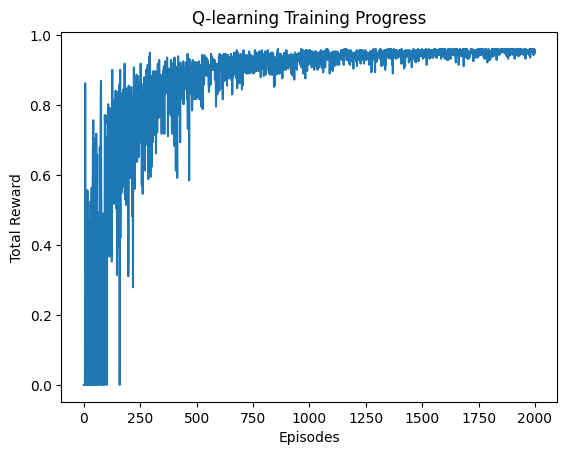

In [9]:
q_table, rewards = tabular_q_learning("MiniGrid-Empty-8x8-v0", episodes=2000)

plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Progress")
plt.show()

After training the agent using **Q-learning**, we will now evaluate its performance in the environment.  

This function runs a **single test episode** using the learned **Q-table** and records the agent's movement as a **GIF**.


Total Reward: 0.961328125


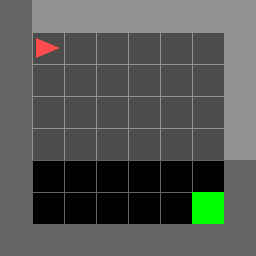

In [10]:
# def run_learned_value(env_name, q_table, max_steps=100, gif_path="/content/minigrid_q_learning.gif"):
def run_learned_value(env_name, q_table, max_steps=100, gif_path="minigrid_q_learning.gif"):

    env = gym.make(env_name, render_mode="rgb_array")
    obs, info = env.reset()

    # TODO: Retrieve the initial state
    pos = env.unwrapped.agent_pos
    dir = env.unwrapped.agent_dir
    state = (pos[0], pos[1], dir)

    frames = []
    total_reward = 0  # Tracks the total accumulated reward.

    frame = env.render()
    frames.append(frame.copy())

    for _ in range(max_steps):
        # TODO: Select an action based on the learned Q-table.
        if state in q_table:
            action = np.argmax(q_table[state])  # Select the action with the highest Q-value for the current state
        else:
            action = env.action_space.sample()  # If state is not in Q-table, select a random action

        # TODO: Execute the chosen action and observe the outcome.
        obs, reward, terminated, truncated, info = env.step(action)

        # TODO: Update termination condition using terminated/truncated
        done = terminated or truncated
        total_reward += float(reward)  # Update the total reward.

        # TODO: Update the agent's state.
        new_pos = env.unwrapped.agent_pos
        new_dir = env.unwrapped.agent_dir
        state = (new_pos[0], new_pos[1], new_dir)

        frame = env.render()
        frames.append(frame.copy())

        if done:
            break

    env.close()

# Do not modify the follwing code—any changes will result in a score of **0** for this cell and also your training code above.
    imageio.mimsave(gif_path, frames, fps=5)
    print(f"Total Reward: {total_reward}")

    return Image(filename=gif_path)

# ✅ Run the trained agent using the learned value-based policy.
run_learned_value("MiniGrid-Empty-8x8-v0", q_table)


## **Policy-Based Learning**  
- Uses a **policy table** to store action probabilities for each state instead of Q-values.  
- Applies **policy gradient methods** to directly optimize the policy, rather than using the Bellman equation.  
- Uses **softmax action selection**, meaning actions are chosen probabilistically instead of always picking the one with the highest value.  

### **🔑 Key Differences from Value-Based Learning (Q-Learning)**  
| Feature            | Value-Based Learning (Q-Learning) | Policy-Based Learning (Policy Gradient) |
|--------------------|---------------------------------|----------------------------------------|
| **Learning Target** | Learns **Q-values** (action values) | Learns **action probabilities** (policy function) |
| **Action Selection** | Uses **ε-greedy** to choose the best Q-value | Uses **softmax** or a stochastic policy to sample actions |
| **Update Method** | Updates Q-values using the **Bellman equation** | Updates the policy directly using **policy gradients** |
| **Exploration Strategy** | Requires **ε-decay** to balance exploration | Exploration is **inherent** in the policy |
| **Best For** | **Discrete action spaces** (small state spaces) | **Continuous or large action spaces** |

## **📌 Summary**  
- **Q-Learning** learns **what the best action is** by estimating values for each action.  
- **Policy Learning** learns **how to act directly**, optimizing the probability of taking actions.  
- **Policy Learning is better for complex, continuous environments**, while **Value Learning is more efficient in simple, discrete environments**. 🚀

🎯 **How to Get 5 Points?**  
1️⃣ Correctly implement the **policy learning training procedure** (e.g., REINFORCE-style updates).  
2️⃣ The agent must be trained using a **policy-table** and the training loop should update the policy properly.  

3️⃣ After training, successfully **demonstrate the learned policy** in the environment. *(4 points)*  
4️⃣ Generate an **animation (GIF/video)** showing the trained agent running in the environment. *(1 point)*  

5️⃣ You get **5 points only if both** the training procedure is correctly implemented **and** the animation is successfully displayed/generated. 🎉

In [11]:
def tabular_policy_learning(env_name="MiniGrid-Empty-8x8-v0", episodes=5000, alpha=0.1, gamma=0.99):

    env = gym.make(env_name)
    # Initialize an empty policy table to store action probabilities.
    policy_table = dict()

    rewards_per_episode = []

    def get_state(env):
        # TODO: Represent the state using the agent's position and direction.
        pos = env.unwrapped.agent_pos  # Get the agent's position (x, y)
        dir = env.unwrapped.agent_dir  # Get the agent's direction (0-3)
        return (pos[0], pos[1], dir)  # Return a tuple representing

    def softmax(x):
        # TODO: Compute softmax values for an array.
        exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
        return exp_x / np.sum(exp_x)

    for episode in range(episodes):
        obs, info = env.reset()
        state = get_state(env)
        done = False
        total_reward = 0.0
        trajectory = []  # Store (state, action, reward) for policy update

        while not done:
            # TODO: Initialize the policy logits for this state if it is not already present.
            #       The table stores unnormalized preferences (logits), not probabilities.
            if state not in policy_table:
                policy_table[state] = np.zeros(env.action_space.n)  # Initialize logits for all actions to zero

            # TODO: Compute the softmax action distribution pi(a|s) from the state's logits.
            logits = policy_table[state]
            probs = softmax(logits)

            # TODO: Sample an action from pi(a|s).
            action = np.random.choice(env.action_space.n, p=probs)

            # TODO: Execute the action and observe reward and termination flags.
            obs, reward, terminated, truncated, info = env.step(action)
            # modified_reward = reward - 0.05 if not terminated else reward

            # TODO: Mark episode as done if terminated or truncated.
            done = terminated or truncated

            # TODO: Extract the next state representation (must match the training state definition).
            next_state = get_state(env)

            reward -= 0.01 if not terminated else 0  # Optional: Add a small step penalty to encourage shorter paths

            # TODO: Accumulate episode reward for logging.
            total_reward += float(reward)

            # TODO: Store (state, action, reward) for return computation and policy update.
            trajectory.append((state, action, float(reward)))

            # TODO: Move to the next state.
            state = next_state

        rewards_per_episode.append(total_reward)

        # Policy Update (REINFORCE-like on a tabular softmax policy)
        G = 0.0  # discounted return
        for t in reversed(range(len(trajectory))):
            state, action, reward = trajectory[t]

            # TODO: Compute discounted return.
            G = reward + gamma * G

            # TODO: Compute the policy gradient update for softmax logits
            probs = softmax(policy_table[state])  # Get current action probabilities
            
            for a in range(env.action_space.n):
                if a == action:
                    policy_table[state][a] += alpha * (G * (1 - probs[a]))  # Increase preference for taken action
                else:
                    policy_table[state][a] -= alpha * (G * probs[a])  # Decrease preference for other actions

        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_per_episode[-100:])
            print(f"Episode {episode + 1}/{episodes}, Avg Reward: {avg_reward:.4f}")

    env.close()
    return policy_table, rewards_per_episode


Train the agent in **MiniGrid-Empty-8x8** using **policy learning**.  

⚠️ Any changes will result in a score of **0** for your training code above.

Episode 100/2000, Avg Reward: -2.1510
Episode 200/2000, Avg Reward: -1.2906
Episode 300/2000, Avg Reward: -0.1532
Episode 400/2000, Avg Reward: 0.2577
Episode 500/2000, Avg Reward: 0.5976
Episode 600/2000, Avg Reward: 0.7113
Episode 700/2000, Avg Reward: 0.7300
Episode 800/2000, Avg Reward: 0.7109
Episode 900/2000, Avg Reward: 0.7141
Episode 1000/2000, Avg Reward: 0.7933
Episode 1100/2000, Avg Reward: 0.7792
Episode 1200/2000, Avg Reward: 0.7839
Episode 1300/2000, Avg Reward: 0.8074
Episode 1400/2000, Avg Reward: 0.8047
Episode 1500/2000, Avg Reward: 0.8183
Episode 1600/2000, Avg Reward: 0.8313
Episode 1700/2000, Avg Reward: 0.8204
Episode 1800/2000, Avg Reward: 0.8236
Episode 1900/2000, Avg Reward: 0.8344
Episode 2000/2000, Avg Reward: 0.8315


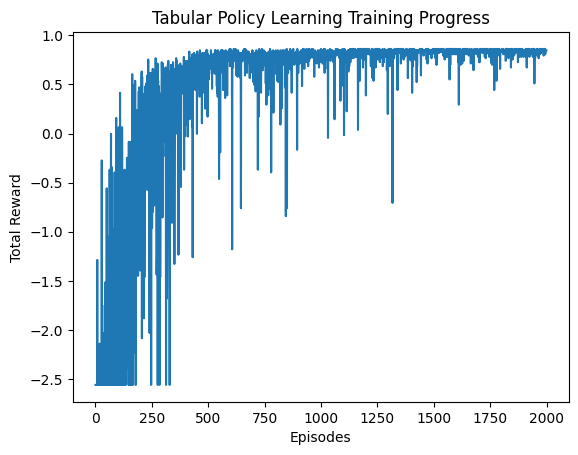

In [12]:
# Train the agent using policy-based learning.
policy_table, rewards = tabular_policy_learning("MiniGrid-Empty-8x8-v0", episodes=2000)

# Plot the training progress.
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Tabular Policy Learning Training Progress")
plt.show()

Now that you have trained your agent using **tabular policy learning**, let's visualize its performance in the **MiniGrid environment**.  

This function runs a **test episode** using the learned **policy table (π-table)** and records the agent's movement as a **GIF**.


Total Reward: 0.9578125


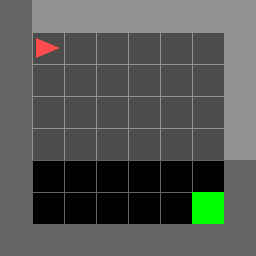

In [13]:
# def run_learned_policy(env_name, policy_table, max_steps=100, gif_path="/content/minigrid_policy_learning.gif"):
def run_learned_policy(env_name, policy_table, max_steps=100, gif_path="minigrid_policy_learning.gif"):
    '''
      Runs a learned policy in a MiniGrid environment and saves an animation GIF.
      :param env_name: (str) Gym environment name
      :param policy_table: (dict) Trained policy table (π)
      :param max_steps: (int) Maximum steps for the episode
      :param gif_path: (str) Path to save the GIF
    '''
    env = gym.make(env_name, render_mode="rgb_array")
    obs, info = env.reset()

    # TODO: Retrieve the initial state
    pos = env.unwrapped.agent_pos
    dir = env.unwrapped.agent_dir
    state = (pos[0], pos[1], dir)

    frames = []
    total_reward = 0  # Track total accumulated reward

    frame = env.render()
    frames.append(frame.copy())

    for _ in range(max_steps):
        # TODO: Choose an action using the learned policy table
        if state in policy_table:
            # action = int(np.argmax(policy_table[state])) # Select the action with the highest preference
            logits = policy_table[state]
            exp_x = np.exp(logits - np.max(logits))
            probs = exp_x / np.sum(exp_x)
            action = np.random.choice(env.action_space.n, p=probs)
        else:
            action = env.action_space.sample() # If state is not in policy table, select a random action

        obs, reward, terminated, truncated, info = env.step(action)
        # TODO: Update termination condition using terminated/truncated
        done = terminated or truncated
        
        total_reward += float(reward)  # Update total reward

        # TODO: Update the agent's state
        new_pos = env.unwrapped.agent_pos
        new_dir = env.unwrapped.agent_dir
        state = (new_pos[0], new_pos[1], new_dir)

        frame = env.render()
        frames.append(frame.copy())

        if done:
            break

    env.close()

# Do not modify the follwing code—any changes will result in a score of **0** for this cell and also your training code above.
    imageio.mimsave(gif_path, frames, fps=5)
    print(f"Total Reward: {total_reward}")

    return Image(filename=gif_path)

# Run the trained policy
run_learned_policy("MiniGrid-Empty-8x8-v0", policy_table)


In this section, you will train an agent using **Q-learning** in the **MiniGrid-BlockedUnlockPickup-v0** environment.  

However, you will likely find that the agent **fails to learn efficiently** in this more complex environment.  

You can comment out the training code to avoid retraining the agent every time you run this notebook.


In [14]:
q_table, rewards = tabular_q_learning("MiniGrid-BlockedUnlockPickup-v0", episodes=2000, epsilon_start=1.0, epsilon_end=0.1, decay_rate=0.9995)

Episode 100/2000, Avg Reward: 0.0000, Epsilon: 0.951
Episode 200/2000, Avg Reward: 0.0000, Epsilon: 0.905
Episode 300/2000, Avg Reward: 0.0000, Epsilon: 0.861
Episode 400/2000, Avg Reward: 0.0000, Epsilon: 0.819
Episode 500/2000, Avg Reward: 0.0000, Epsilon: 0.779
Episode 600/2000, Avg Reward: 0.0000, Epsilon: 0.741
Episode 700/2000, Avg Reward: 0.0000, Epsilon: 0.705
Episode 800/2000, Avg Reward: 0.0000, Epsilon: 0.670
Episode 900/2000, Avg Reward: 0.0000, Epsilon: 0.638
Episode 1000/2000, Avg Reward: 0.0000, Epsilon: 0.606
Episode 1100/2000, Avg Reward: 0.0000, Epsilon: 0.577
Episode 1200/2000, Avg Reward: 0.0000, Epsilon: 0.549
Episode 1300/2000, Avg Reward: 0.0000, Epsilon: 0.522
Episode 1400/2000, Avg Reward: 0.0000, Epsilon: 0.496
Episode 1500/2000, Avg Reward: 0.0000, Epsilon: 0.472
Episode 1600/2000, Avg Reward: 0.0000, Epsilon: 0.449
Episode 1700/2000, Avg Reward: 0.0000, Epsilon: 0.427
Episode 1800/2000, Avg Reward: 0.0000, Epsilon: 0.406
Episode 1900/2000, Avg Reward: 0.0000

Now that we have trained an agent using **Q-learning** on **MiniGrid-BlockedUnlockPickup-v0**, let's evaluate its performance.

You can also comment out this cell.

Total Reward: 0.0


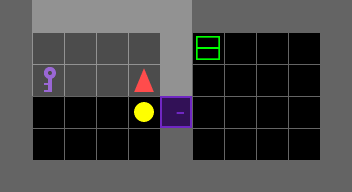

In [15]:
# Run the trained value once
run_learned_value("MiniGrid-BlockedUnlockPickup-v0", q_table)


## **Reward Shaping**  

If the agent only receives a reward upon reaching the goal, how can it learn that **picking up the key** and **opening the door** are necessary steps?  

This is where **Reward Shaping** comes into play.  

### **📌 What is Reward Shaping?**  
Reward shaping is a technique used in **reinforcement learning (RL)** to provide additional rewards that help guide the agent toward desirable behaviors. Instead of giving a reward only when the agent completes the task, intermediate rewards are introduced to **reinforce progress** toward the goal.  

### **🛠 Why Use Reward Shaping?**  
- **Speeds up learning**: Helps the agent learn useful behaviors more quickly.  
- **Encourages exploration**: Provides incentives for discovering key steps in complex environments.  
- **Reduces sparse reward problems**: Addresses situations where rewards are given only at the end of an episode, making learning difficult.  

### **🎯 Example: Reward Shaping in MiniGrid-BlockedUnlockPickup**  
In **MiniGrid-BlockedUnlockPickup-v0**, the agent must:  
1. **Move the blocking ball out of the way**  
2. **Find and pick up the key**  
3. **Navigate to the locked door and unlock it**  
4. **Go inside and pick up the box to finish the episode**  

Without reward shaping, the agent may struggle to associate early sub-goals—especially **clearing the blockage** and **obtaining the key**—with the delayed terminal reward, making learning slow and unstable.

### **🚀 Key Takeaway**  
Reward shaping **bridges the gap between sparse rewards and effective learning**. It guides the agent by providing structured feedback, helping it navigate complex tasks more efficiently.

🎯 **How to Get 20 Points? (Q-table + Reward Shaping Evaluation)**

1️⃣ Successfully implement **reward shaping** to train an agent.  
2️⃣ The agent should learn to navigate the environment using **Q-tables** (not a neural network).  
3️⃣ After training, evaluate your learned Q-table by running **20 episodes** (e.g., `run_learned_value_adjust_eps(..., n_episodes=20)`).  
4️⃣ **Success definition (per episode):** if the agent obtains **any positive reward (`reward > 0`)** during that episode, it counts as **1 success**.  
5️⃣ You must generate an **animation (GIF)** showing the trained agent’s behavior during evaluation.

✅ **Scoring is based on the number of successes out of 20 episodes:**
- **15–20 successes → 20 points**
- **11–14 successes → 15 points**
- **7–10 successes → 10 points**
- **3–6 successes → 5 points**
- **0–2 successes → 0 points**


In [ ]:
import numpy as np
import gymnasium as gym

def tabular_q_learning_adjust(
    env_name="MiniGrid-BlockedUnlockPickup-v0",
    episodes=6500,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.1,
    decay_rate=0.9997,
    reward_shaping=True,
    q_table=None,
    debug=False,
):

    env = gym.make(env_name)
    base_env = env.unwrapped

    if q_table is None:
        q_table = {}

    rewards_per_episode = []
    epsilon = epsilon_start

    env_rewards_100 = []
    shaped_rewards_100 = []
    success_100 = []

    # Helper functions
    def _iter_grid_objects():
        grid = base_env.grid
        for x in range(grid.width):
            for y in range(grid.height):
                obj = grid.get(x, y)
                if obj is not None:
                    yield x, y, obj

    def _find_first_obj(obj_type):
        for x, y, obj in _iter_grid_objects():
            if getattr(obj, "type", None) == obj_type:
                return x, y, obj
        return None, None, None

    def _carrying_type():
        carry = base_env.carrying
        return carry.type if carry is not None else None

    def _door_state():
        x, y, door = _find_first_obj("door")
        if door is not None:
            return door.is_open
        return False
    
    def _ball_blocking():
        dx, dy, _ = _find_first_obj("door")
        if dx is None:
            return False

        carry = _carrying_type()
        if carry == "ball":
            bx, by = base_env.front_pos
        else:
            bx, by, _ = _find_first_obj("ball")
            if bx is None:
                return False

        dist = abs(bx - dx) + abs(by - dy)
        return dist <= 1

    def _get_front_obj():
        fwd_pos = base_env.front_pos
        fwd_cell = base_env.grid.get(*fwd_pos)
        if fwd_cell is None:
            return "empty"

        if fwd_cell.type in ("ball", "key", "door", "box"):
            return fwd_cell.type
        return "wall"

    def get_state():
        pos = base_env.agent_pos
        dir = base_env.agent_dir
        carry = _carrying_type()
        door_open = _door_state()
        ball_blocking = _ball_blocking()

        phase = None
        target_obj = None
        if carry is None and ball_blocking:
            phase = "pick ball"
            target_obj = "ball"
        elif carry == "ball":
            phase = "drop ball"
        elif carry is None and not door_open and not ball_blocking:
            phase = "pick key"
            target_obj = "key"
        elif carry == "key" and not door_open and not ball_blocking:
            phase = "open door"
            target_obj = "door"
        elif carry == "key" and (door_open or ball_blocking):
            phase = "drop key"
        else: # carry is None and door_open and not ball_blocking
            phase = "pick box"
            target_obj = "box"

        tx, ty = None, None
        if target_obj is not None:
            tx, ty, _ = _find_first_obj(target_obj)

        target_rel = (
            int(np.sign(tx - pos[0])) if tx is not None else 0,
            int(np.sign(ty - pos[1])) if ty is not None else 0
        )

        return (dir, phase, target_rel, target_obj, _get_front_obj())

    def _get_potential(phase):
        if phase == "pick ball":
            return 5.0
        elif phase == "drop ball":
            return 10.0
        elif phase == "pick key":
            return 15.0
        elif phase == "open door":
            return 20.0
        elif phase == "drop key":
            return 25.0
        elif phase == "pick box":
            return 30.0
        else:
            return 0.0

    def _reset_env():
        return env.reset()

    def _step_env(action):
        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)
        return obs, float(reward), bool(terminated), bool(truncated), info, done

    for episode in range(episodes):
        obs, info = _reset_env()

        total_reward = 0.0
        total_env_reward = 0.0
        total_shaped_reward = 0.0

        done = False
        step_count = 0

        state = get_state()

        while not done:
            step_count += 1

            if state not in q_table:
                q_table[state] = np.zeros(env.action_space.n, dtype=np.float32)

            # Choose an action using an exploration strategy such as epsilon-greedy.
            if np.random.rand() < epsilon:
                action = env.action_space.sample() # Explore: select a random action
            else:
                action = int(np.argmax(q_table[state])) # Exploit: select the action with max Q-value

            prev_carry = _carrying_type()
            prev_door_open = _door_state()
            prev_pos = base_env.agent_pos
            prev_potential = _get_potential(state[1])

            # Execute the selected action in the environment.
            obs, env_reward, terminated, truncated, info, done = _step_env(action)
            done = bool(terminated or truncated)
            next_state = get_state()

            next_carry = _carrying_type()
            next_door_open = _door_state()
            next_pos = base_env.agent_pos
            next_potential = _get_potential(next_state[1])

            shaped_reward = 0.0

            if reward_shaping:
                shaped_reward -= 0.05 # Add a small step penalty to encourage shorter paths

                # GPS-like Reward Shaping
                target_rel = state[2]
                move_x = next_pos[0] - prev_pos[0]
                move_y = next_pos[1] - prev_pos[1]
                if move_x != 0 or move_y != 0:
                    if target_rel[0] != 0:
                        if move_x == target_rel[0]:
                            shaped_reward += 0.1
                        elif move_x == -target_rel[0]:
                            shaped_reward -= 0.1
                        
                    if target_rel[1] != 0:
                        if move_y == target_rel[1]:
                            shaped_reward += 0.1
                        elif move_y == -target_rel[1]:
                            shaped_reward -= 0.1

                # Potential-based Reward Shaping
                potential_diff = next_potential - prev_potential
                shaped_reward += potential_diff

                # Penalties
                # 1. Hit Wall
                if action == 2 and move_x == 0 and move_y == 0:
                    shaped_reward -= 0.1
                
                # 2. Play with Door
                if prev_door_open and not next_door_open:
                    shaped_reward -= 0.5

                # 3. Drop Key blocking the door
                if prev_carry == "key" and next_carry is None:
                    kx, ky, _ = _find_first_obj("key")
                    dx, dy, _ = _find_first_obj("door")
                    
                    if kx is not None and dx is not None:
                        dist_to_door = abs(kx - dx) + abs(ky - dy)
                        
                        if dist_to_door <= 1:
                            shaped_reward -= 5.5

            if terminated: # Got success reward
                shaped_reward += 50.0

            reward = float(env_reward) + float(shaped_reward)

            total_env_reward += float(env_reward)
            total_shaped_reward += float(shaped_reward)
            total_reward += float(reward)

            if next_state not in q_table:
                q_table[next_state] = np.zeros(env.action_space.n, dtype=np.float32)

            best_next_action = int(np.argmax(q_table[next_state]))
            td_target = reward + (0.0 if done else gamma) * q_table[next_state][best_next_action]
            q_table[state][action] += alpha * (td_target - q_table[state][action])

            state = next_state

            if debug and (step_count % 50 == 0):
                current_dir, current_phase, current_rel, current_front = state
                
                print(
                    f"[dbg] step={step_count} | phase: {current_phase: <10} | "
                    f"front: {current_front: <6} | rel: {current_rel} | "
                    f"env_r: {env_reward:.2f} | shaped_r: {shaped_reward:.2f} | "
                    f"potential: {_get_potential(current_phase)}"
                )

        rewards_per_episode.append(total_reward)
        env_rewards_100.append(total_env_reward)
        shaped_rewards_100.append(total_shaped_reward)

        success_100.append(1.0 if (terminated or _carrying_type() == "box") else 0.0)

        epsilon = max(epsilon_end, epsilon * decay_rate)

        if (episode + 1) % 100 == 0:
            avg_total = float(np.mean(rewards_per_episode[-100:]))
            avg_env = float(np.mean(env_rewards_100[-100:]))
            avg_shaped = float(np.mean(shaped_rewards_100[-100:]))
            succ = float(np.mean(success_100[-100:]))
            print(
                f"🚀 Episode {episode + 1}/{episodes}, "
                f"Avg Total: {avg_total:.2f}, Avg Env: {avg_env:.2f}, Avg Shaped: {avg_shaped:.2f}, "
                f"Success(100ep): {succ:.2f}, Epsilon: {epsilon:.3f}"
            )

    env.close()
    return q_table, rewards_per_episode

Training with reward shapping in the MiniGrid-BlockedUnlockPickup-v0 Environment.

⚠️ **Any changes will result in a score of **0** for your training code above.

🚀 Training MiniGrid-BlockedUnlockPickup-v0
🚀 Episode 100/6500, Avg Total: -21.74, Avg Env: 0.00, Avg Shaped: -21.74, Success(100ep): 0.00, Epsilon: 0.951
🚀 Episode 200/6500, Avg Total: -18.00, Avg Env: 0.00, Avg Shaped: -18.00, Success(100ep): 0.02, Epsilon: 0.905
🚀 Episode 300/6500, Avg Total: -13.22, Avg Env: 0.04, Avg Shaped: -13.26, Success(100ep): 0.09, Epsilon: 0.861
🚀 Episode 400/6500, Avg Total: -11.49, Avg Env: 0.04, Avg Shaped: -11.53, Success(100ep): 0.12, Epsilon: 0.819
🚀 Episode 500/6500, Avg Total: -9.39, Avg Env: 0.07, Avg Shaped: -9.45, Success(100ep): 0.13, Epsilon: 0.779
🚀 Episode 600/6500, Avg Total: -9.56, Avg Env: 0.05, Avg Shaped: -9.61, Success(100ep): 0.13, Epsilon: 0.741
🚀 Episode 700/6500, Avg Total: -8.19, Avg Env: 0.05, Avg Shaped: -8.24, Success(100ep): 0.10, Epsilon: 0.705
🚀 Episode 800/6500, Avg Total: -4.66, Avg Env: 0.08, Avg Shaped: -4.74, Success(100ep): 0.15, Epsilon: 0.670
🚀 Episode 900/6500, Avg Total: -12.73, Avg Env: 0.03, Avg Shaped: -12.76, Suc

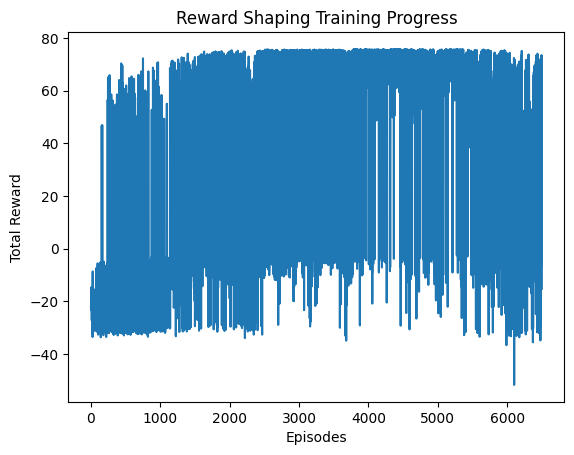

In [43]:
# Run the training.
print("🚀 Training MiniGrid-BlockedUnlockPickup-v0")
q_table, rewards = tabular_q_learning_adjust("MiniGrid-BlockedUnlockPickup-v0", episodes=6500)
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Reward Shaping Training Progress")
plt.show()

Now that you have trained your agent using reward shaping, let's visualize its performance in the MiniGrid-BlockedUnlockPickup Environment.
⚠️ Do not modify this cell, except for bringing over the necessary helper functions and get_state() from your training code. Any other changes will result in a score of 0 for your training code above.

Success: 0/20
Episode rewards: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


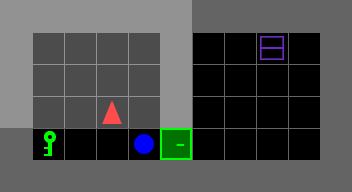

In [44]:
def run_learned_value_adjust_eps(
    env_name="MiniGrid-BlockedUnlockPickup-v0",
    q_table=None,
    n_episodes=20,
    max_steps=150,
    # gif_path="/content/minigrid_q_learning_10eps.gif",
    gif_path="minigrid_q_learning_10eps.gif",
    live_display=True,
    display_every=1,
    fps=5,
    pause_between_episodes_sec=0.5,
    seed=0,
):
    """
    Runs a learned Q-table policy for n_episodes episodes, counts successes, and saves one GIF.

    Success definition:
      - success = (reward > 0) at any step (MiniGrid sparse-reward tasks typically only reward success)
    Seeding:
      - episode seed = seed + ep
      - env.reset(seed=episode_seed) and env.action_space.seed(episode_seed)
    """
    if q_table is None:
        q_table = {}

    env = gym.make(env_name, render_mode="rgb_array")
    base_env = env.unwrapped

    # TODO: Bring the helper functions and state design from your training
    # code to this evaluation function. The state representation used here
    # must match the one used during training; otherwise, the learned Q-table
    # cannot be applied correctly.

    def _iter_grid_objects():
        grid = base_env.grid
        for x in range(grid.width):
            for y in range(grid.height):
                obj = grid.get(x, y)
                if obj is not None:
                    yield x, y, obj

    def _find_first_obj(obj_type):
        for x, y, obj in _iter_grid_objects():
            if getattr(obj, "type", None) == obj_type:
                return x, y, obj
        return None, None, None

    def _carrying_type():
        carry = base_env.carrying
        return carry.type if carry is not None else None

    def _door_state():
        x, y, door = _find_first_obj("door")
        if door is not None:
            return door.is_open
        return False
    
    def _ball_blocking():
        dx, dy, _ = _find_first_obj("door")
        if dx is None:
            return False

        carry = _carrying_type()
        if carry == "ball":
            bx, by = base_env.front_pos
        else:
            bx, by, _ = _find_first_obj("ball")
            if bx is None:
                return False

        dist = abs(bx - dx) + abs(by - dy)
        return dist <= 1

    def _get_front_obj():
        fwd_pos = base_env.front_pos
        fwd_cell = base_env.grid.get(*fwd_pos)
        if fwd_cell is None:
            return "empty"

        if fwd_cell.type in ("ball", "key", "door", "box"):
            return fwd_cell.type
        return "wall"

    def get_state():
        pos = base_env.agent_pos
        dir = base_env.agent_dir
        carry = _carrying_type()
        door_open = _door_state()
        ball_blocking = _ball_blocking()

        phase = None
        target_obj = None
        if carry is None and ball_blocking:
            phase = "pick ball"
            target_obj = "ball"
        elif carry == "ball":
            phase = "drop ball"
        elif carry is None and not door_open and not ball_blocking:
            phase = "pick key"
            target_obj = "key"
        elif carry == "key" and not door_open and not ball_blocking:
            phase = "open door"
            target_obj = "door"
        elif carry == "key" and (door_open or ball_blocking):
            phase = "drop key"
        else: # carry is None and door_open and not ball_blocking
            phase = "pick box"
            target_obj = "box"

        tx, ty = None, None
        if target_obj is not None:
            tx, ty, _ = _find_first_obj(target_obj)

        target_rel = (
            int(np.sign(tx - pos[0])) if tx is not None else 0,
            int(np.sign(ty - pos[1])) if ty is not None else 0
        )

        return (dir, phase, target_rel, _get_front_obj(), target_obj) # Add more information!

    # -----------------------------
    # Rollout over episodes
    # -----------------------------
    frames = []
    success_count = 0
    ep_rewards = []

    handle = None
    fig, axp, im = None, None, None

    for ep in range(n_episodes):
        ep_seed = int(seed) + int(ep)
        env.action_space.seed(ep_seed)
        obs, info = env.reset(seed=ep_seed)

        state = get_state()
        total_reward = 0.0
        success = False

        frame = env.render()
        frames.append(frame.copy())

        if live_display and (handle is None):
            fig, axp = plt.subplots()
            im = axp.imshow(frame)
            axp.axis("off")
            axp.set_title(f"Ep {ep+1}/{n_episodes} | Step 0")
            handle = display(fig, display_id=True)
            plt.close(fig)

        for t in range(max_steps):
            action = env.action_space.sample() if state not in q_table else int(np.argmax(q_table[state]))

            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            r = float(reward)
            total_reward += r
            if r > 0.0:
                success = True

            state = get_state()

            frame = env.render()
            frames.append(frame.copy())

            if live_display and (t % display_every == 0):
                im.set_data(frame)
                axp.set_title(
                    f"Ep {ep+1}/{n_episodes} | Step {t+1} | action={action} "
                    f"| ep_reward={total_reward:.2f} | success={int(success)}"
                )
                handle.update(fig)

            if done:
                break

        success_count += int(success)
        ep_rewards.append(total_reward)

        if pause_between_episodes_sec and pause_between_episodes_sec > 0:
            k = int(round(pause_between_episodes_sec * fps))
            if k > 0:
                last_frame = frames[-1]
                for _ in range(k):
                    frames.append(last_frame.copy())

    env.close()

    imageio.mimsave(gif_path, frames, fps=fps)

    print(f"Success: {success_count}/{n_episodes}")
    print("Episode rewards:", [round(r, 4) for r in ep_rewards])

    return Image(filename=gif_path)

run_learned_value_adjust_eps("MiniGrid-BlockedUnlockPickup-v0", q_table, live_display=False, display_every=1, seed=0)



🎥 正在產出 Seed 0 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


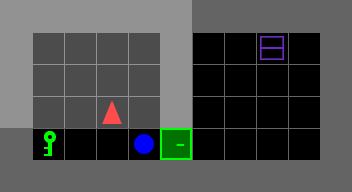

----------------------------------------
🎥 正在產出 Seed 1 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


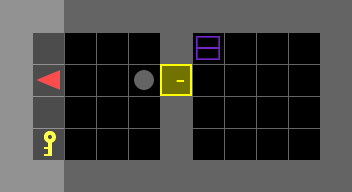

----------------------------------------
🎥 正在產出 Seed 2 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


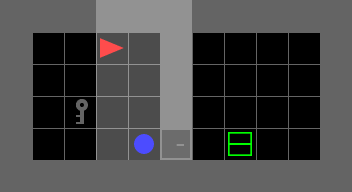

----------------------------------------
🎥 正在產出 Seed 3 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


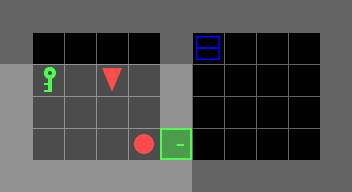

----------------------------------------
🎥 正在產出 Seed 4 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


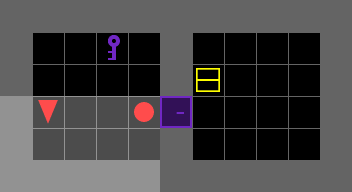

----------------------------------------
🎥 正在產出 Seed 5 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


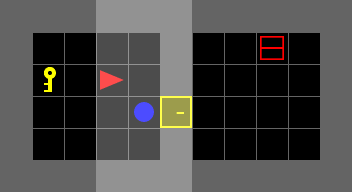

----------------------------------------
🎥 正在產出 Seed 6 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


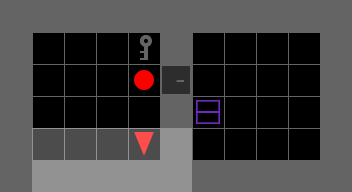

----------------------------------------
🎥 正在產出 Seed 7 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


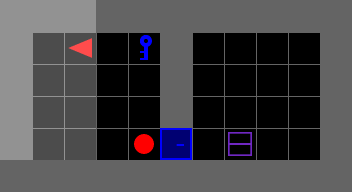

----------------------------------------
🎥 正在產出 Seed 8 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


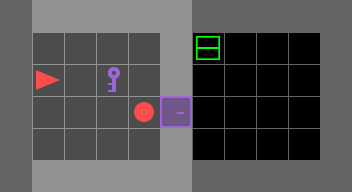

----------------------------------------
🎥 正在產出 Seed 9 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


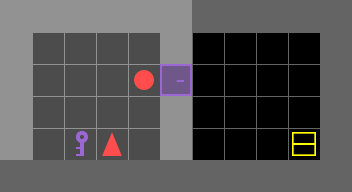

----------------------------------------
🎥 正在產出 Seed 10 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


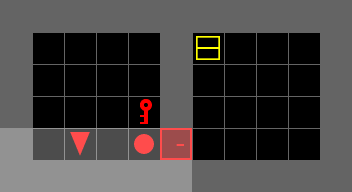

----------------------------------------
🎥 正在產出 Seed 11 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


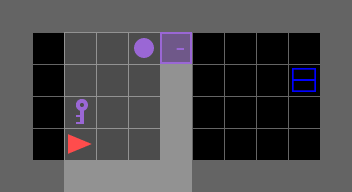

----------------------------------------
🎥 正在產出 Seed 12 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


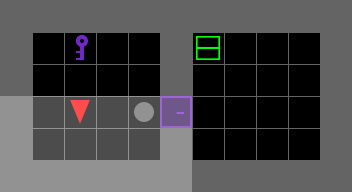

----------------------------------------
🎥 正在產出 Seed 13 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


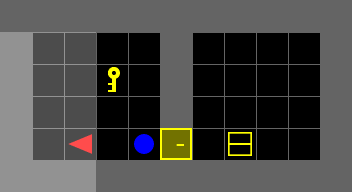

----------------------------------------
🎥 正在產出 Seed 14 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


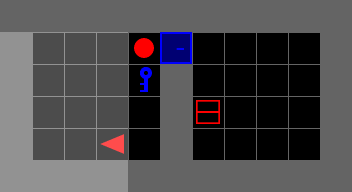

----------------------------------------
🎥 正在產出 Seed 15 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


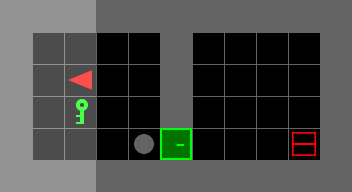

----------------------------------------
🎥 正在產出 Seed 16 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


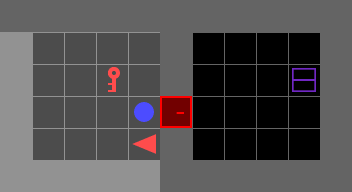

----------------------------------------
🎥 正在產出 Seed 17 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


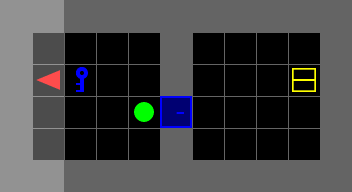

----------------------------------------
🎥 正在產出 Seed 18 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


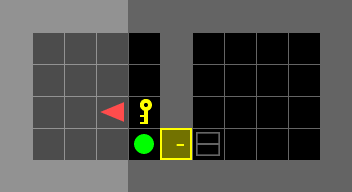

----------------------------------------
🎥 正在產出 Seed 19 的專屬動畫...
Success: 0/1
Episode rewards: [0.0]


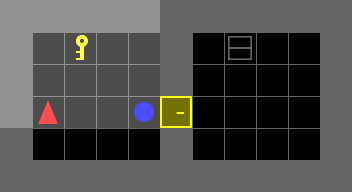

----------------------------------------


In [45]:
from IPython.display import Image, display

# 🎯 假設你剛剛跑完 20 局 (對應 seed 0~19)
# 找出你感興趣的幾局（例如第 5 局 seed=4，跟第 12 局 seed=11），把它們填進這個 list
target_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
# target_seeds = [9, 11]

for s in target_seeds:
    print(f"🎥 正在產出 Seed {s} 的專屬動畫...")
    gif_name = f"minigrid_test_seed_{s}.gif"
    
    # 呼叫你原本已經定義好的 function
    run_learned_value_adjust_eps(
        env_name="MiniGrid-BlockedUnlockPickup-v0",
        q_table=q_table,
        n_episodes=1,        # 🌟 關鍵：一次只跑 1 局，GIF 就不會拖泥帶水
        seed=s,              # 🌟 關鍵：直接指定你要看的環境 seed
        gif_path=gif_name,
        live_display=False,  # 關掉逐幀即時顯示，產檔速度會飛快
        display_every=1
    )
    
    # 直接在 Notebook 顯示這個獨立的短 GIF
    display(Image(filename=gif_name))
    print("-" * 40)

# **Question 3: Implementing Tabular Learning with PyTorch**  

So far, we have implemented **Tabular Q-learning** using **NumPy** to store and update the Q-table.  
However, in real-world **reinforcement learning**, deep learning frameworks like **PyTorch** are often used to handle **large state spaces** and optimize learning.  

In this question, we will still use **tabular learning**, but instead of **NumPy**, we will implement **Q-learning** and **Policy Learning** using **PyTorch**.  


✅ **Q-Learning Implementation (10 Points)**  
- Correctly implements **Q-learning using PyTorch tensors** instead of NumPy.  
- Successfully **trains the agent** and **demonstrates an animation of reaching the goal**.  

✅ **Policy Learning Implementation (10 Points)**  
- Correctly implements **policy-based learning using PyTorch**, including a **softmax policy**.  
- Successfully **trains the agent** and **demonstrates an animation of reaching the goal**.  

🚀 **Full Score (20 Points)**: If both Q-learning and Policy Learning are implemented correctly and the agent **successfully reaches the goal**, you have **earned all 20 points! 🎉**  

In [ ]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

def get_agent_state(env):
    # TODO: Represent the state using the agent's position and direction.
    agent_pos = tuple(env.unwrapped.agent_pos)
    direction = env.unwrapped.agent_dir
    x,y = agent_pos
    return ( x , y , direction)



class PyTorchQTable:
    def __init__(self, state_size, action_size, lr=0.1):
        """
          PyTorch Q-table Implementation.
          - Stores Q-values as a PyTorch tensor.
          - Uses gradient-based updates instead of direct assignment.
          - Optimizes learning using Mean Squared Error (MSE).
        """
        self.state_size = state_size
        self.action_size = action_size

        # TODO: Initialize the Q-table as a PyTorch tensor.


        # TODO: Use Stochastic Gradient Descent (SGD) for optimization.



        # TODO: Use Mean Squared Error (MSE) loss for training.


    def update(self, state, action, target):
        """
        Update the Q-value using PyTorch optimization.
        """
        self.optimizer.zero_grad()

        # TODO: Retrieve the current Q-value.


        # TODO: Compute the MSE loss.


        # TODO: Perform backpropagation.


        # TODO: Perform gradient descent.

    def get_action(self, state, epsilon):
        # TODO: Implements ε-greedy action selection.





def train_pytorch_q_learning(
    env_name="MiniGrid-Empty-8x8-v0",
    episodes=2000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.1,
    decay_rate=0.999,
    seed=0
):

    env = gym.make(env_name)
    base_env = env.unwrapped
    state_size = (base_env.width, base_env.height, 4)  # (x, y, direction)
    action_size = env.action_space.n

    q_table = PyTorchQTable(state_size, action_size, lr=alpha)
    epsilon = epsilon_start

    for episode in range(episodes):
        obs, _ = env.reset(seed=seed + episode)
        state = get_agent_state(env)

        terminated = False
        truncated = False
        total_reward = 0.0

        while not (terminated or truncated):
            action = q_table.get_action(state, epsilon)

            obs, reward, terminated, truncated, _ = env.step(action)
            next_state = get_agent_state(env)

            # TODO: Implement Q-learning using PyTorch Q-table.

            q_table.update(state, action, target)

            state = next_state
            total_reward += float(reward)

        epsilon = max(epsilon_end, epsilon * decay_rate)

        if (episode + 1) % 100 == 0:
            print(f"Episode {episode + 1}/{episodes}, Total Reward: {total_reward}, Epsilon: {epsilon:.3f}")

    env.close()
    return q_table





Train the agent in MiniGrid-Empty-8x8 with PyTorch Q-learning.

⚠️ **Any changes** will result in a score of **0** for your training code above.

In [ ]:
print("🚀 Training PyTorch Q-learning on MiniGrid-Empty-8x8")
q_table = train_pytorch_q_learning("MiniGrid-Empty-8x8-v0", episodes=2000)

In [ ]:
import gymnasium as gym
import imageio
from IPython.display import Image

def run_pytorch_q_learning(env_name="MiniGrid-Empty-8x8-v0", q_table=None, max_steps=100, gif_path="/content/minigrid_q_learning.gif"):

    env = gym.make(env_name, render_mode="rgb_array")
    obs, _ = env.reset()
    state = get_agent_state(env)

    frames = []
    total_reward = 0.0

    frames.append(env.render())

    for _ in range(max_steps):
        action = q_table.get_action(state, epsilon=0.0)

        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += float(reward)
        state = get_agent_state(env)


        frames.append(env.render())

        if terminated or truncated:
            break

    env.close()

#Do not modify the code below—any changes will result in a score of 0 for your training code above.
    imageio.mimsave(gif_path, frames, fps=5)
    print(f"Total Reward: {total_reward}")

    return Image(filename=gif_path)

run_pytorch_q_learning("MiniGrid-Empty-8x8-v0", q_table)

Instead of directly updating **Q-values**, we will now train an explicit **policy** using **Softmax Policy Gradients**.  

### **📌 What is Softmax Policy Gradient?**  
In **value-based reinforcement learning** (e.g., Q-learning), an agent **learns a Q-table** that estimates the value of each action in a given state. However, instead of storing and updating Q-values, **policy-based methods** directly learn a **policy** that maps states to actions.  

The **Softmax Policy Gradient** approach uses a **probabilistic policy representation**, where action selection is based on a **Softmax function** applied to policy scores. This enables the agent to explore actions **proportionally to their estimated effectiveness**, rather than always selecting the highest-value action.  

### **🛠 How Does It Work?**  
1. **The policy is represented by a probability distribution** over actions for each state.  
2. **The agent selects an action using Softmax probabilities**, rather than choosing greedily based on a Q-table.  
3. **The policy is updated using gradient ascent**, optimizing a loss function (e.g., Cross-Entropy Loss).  
4. **The agent improves its action selection strategy over time** by reinforcing actions that lead to higher rewards.  

### **🎯 Why Use Softmax Policy Gradients?**  
- ✅ **Handles large state spaces** more effectively than tabular Q-learning.  
- ✅ **Encourages exploration** by selecting actions probabilistically instead of always taking the best-known action.  
- ✅ **More suitable for stochastic environments**, where actions should not always be deterministic.  
- ✅ **Lays the foundation for deep policy-based RL**, such as REINFORCE and Actor-Critic methods.  

In this section, we will implement **policy learning** using **PyTorch** and train the agent using the **Softmax Policy Gradient method**.


In [ ]:
import torch.nn.functional as F
def get_agent_state(env):
    # TODO: Represent the state using the agent's position and direction.

class PyTorchPolicy:
    def __init__(self, state_size, action_size, lr=0.1):
        '''
          Implements a Softmax Policy using PyTorch.
          - Uses **log probabilities** for policy updates.
          - Optimized using **REINFORCE** with policy gradients.
        '''
        self.state_size = state_size
        self.action_size = action_size

        # TODO: Initialize the policy tensor (logits)


        # TODO: Use **Adam optimizer** for policy optimization.


    def get_action(self, state):

        # TODO: Sample an action based on **Softmax probabilities**.


        return action  # Return log probability

    def update(self, state, action, reward):
        self.optimizer.zero_grad()

        action_tensor = torch.tensor(action, dtype=torch.long)

        # TODO: Fetch the policy logits for the given state from the logits table.


        # TODO: Compute log-probabilities with log_softmax, then select log-prob of the taken action.


        # TODO: Compute the REINFORCE loss: negative reward times log-prob of the taken action.


        # TODO: Backpropagate gradients through the logits table.


        # TODO: Take an optimizer step to update parameters (gradient descent).



def train_pytorch_policy_learning(env_name="MiniGrid-Empty-8x8-v0", episodes=5000, alpha=0.05, gamma=0.99):
    '''
      Train Policy Learning using **Softmax Policy Gradient**.
      - Uses **log probability gradient**.
      - Optimizes policy using **Adam**.
    '''
    env = gym.make(env_name)
    base_env = env.unwrapped
    state_size = (base_env.width, base_env.height, 4)
    action_size = env.action_space.n

    policy_model = PyTorchPolicy(state_size, action_size, lr=alpha)


    for episode in range(episodes):
        obs, _ = env.reset()

        state = get_agent_state(env)

        done = False
        total_reward = 0
        trajectory = []


        while not done:
            # TODO: Sample an action from the current stochastic policy (e.g., softmax over logits).


            # TODO: Step the environment with the sampled action and obtain (obs, reward, termination flags).

            done = done or truncated
            trajectory.append((state, action, reward))
            state = get_agent_state(env)
            total_reward += reward

        # Compute discounted returns G_t
        G = 0
        stored_G = []

        # TODO: Traverse the trajectory backward to compute discounted return:


        # TODO: Iterate forward again; for each timestep t, retrieve its return G_t
        #         and update the policy using REINFORCE: loss = -G_t * log π(a_t | s_t)

            policy_model.update(state, action, G)



        # Print progress every 100 episodes.
        if (episode + 1) % 100 == 0:
            print(f"🚀 Episode {episode + 1}/{episodes}, Total Reward: {total_reward}")

    env.close()
    return policy_model


Train the agent in MiniGrid-Empty-8x8 with PyTorch policy learning.

⚠️ **You can only adjust the episodes in this cell**—any others changes will result in a score of **0** for your training code above.

In [ ]:
print("🚀 Training PyTorch Policy Learning on MiniGrid-Empty-8x8")
policy_model = train_pytorch_policy_learning("MiniGrid-Empty-8x8-v0", episodes=2000)

Now that you have trained your agent using **PyTorch policy learning**, let's visualize its performance in the **MiniGrid environment**.  

This function runs a **test episode** using the learned **policy table (π-table)** and records the agent's movement as a **GIF**.

⚠️ Do not modify this cell—any changes will result in a score of 0 for your training code above.


In [ ]:
def run_pytorch_policy_learning(env_name, policy_model, max_steps=100, gif_path="/content/minigrid_policy_learning.gif"):

    env = gym.make(env_name, render_mode="rgb_array")
    obs, _ = env.reset()
    state = get_agent_state(env)

    frames = []
    total_reward = 0.0

    frames.append(env.render())

    for _ in range(max_steps):
        action = policy_model.get_action(state)
        obs, reward, terminated, truncated, _ = env.step(action)

        total_reward += float(reward)
        state = get_agent_state(env)

        frames.append(env.render())

        if terminated or truncated:
            break

    env.close()

    imageio.mimsave(gif_path, frames, fps=5)
    print(f"Total Reward: {total_reward}")
    return Image(filename=gif_path)

print("🚀 Running PyTorch Policy Learning agent")
run_pytorch_policy_learning("MiniGrid-Empty-8x8-v0", policy_model)